In [1]:
from pathlib import Path
from typing import Dict, Any, Optional, Literal, List, Tuple

import json
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


GroupMode = Literal["sensors", "windows"]
RankingSource = Literal["weights", "randomavg", "timetrust"]
YScale = Literal["linear", "log"]
Transform = Literal["raw", "delta", "ratio"]


def plot_rankings_metric_evolution_2x2_ieee(
    dataset: str,
    window_tag: str,
    hidden_tag: str,
    metric: str = "rmse",
    baselines_root: str | Path = "mlp_baselines",
    save_path: Optional[str | Path] = None,
    y_scale: YScale = "linear",
    transform: Transform = "raw",
) -> None:
    """
    IEEE-style compact 2x2 grid:
      Columns: Sensors | Windows
      Rows:    Train   | Val

    X-axis = number of remaining groups (starts at n_groups for baseline, ends at 1),
    displayed decreasing left->right (baseline -> 1).
    """

    baselines_root = Path(baselines_root)
    json_path = (
        baselines_root
        / dataset
        / window_tag
        / hidden_tag
        / "rankings"
        / "rankings_metrics_evolution.json"
    )
    if not json_path.exists():
        raise FileNotFoundError(f"Missing metrics evolution JSON at: {json_path}")

    with open(json_path, "r", encoding="utf-8") as f:
        data: Dict[str, Any] = json.load(f)

    results: Dict[str, Any] = data.get("results", {})
    if not results:
        raise ValueError(f"No 'results' found in: {json_path}")

    train_key = f"train_{metric}"
    val_key = f"val_{metric}"

    sources: List[Tuple[RankingSource, str]] = [
        ("weights", "weights"),
        ("randomavg", "randomavg"),
        ("timetrust", "timetrust"),
    ]

    def _get_vec(group_mode: GroupMode, src: str) -> Optional[List[Dict[str, Any]]]:
        k = f"{group_mode}.{src}"
        if k not in results:
            return None
        vec = results[k].get("metrics_vector", None)
        if not vec:
            return None
        return vec

    def _infer_n_groups(group_mode: GroupMode) -> int:
        if group_mode == "sensors" and "M" in data:
            return int(data["M"])
        if group_mode == "windows" and "W" in data:
            return int(data["W"])
        for _, src in sources:
            vec = _get_vec(group_mode, src)
            if vec is not None:
                return max(1, len(vec) - 1)
        raise ValueError(f"Could not infer n_groups for {group_mode}")

    n_sensors = _infer_n_groups("sensors")
    n_windows = _infer_n_groups("windows")

    # remaining = n_groups - removed (baseline removed=0 -> remaining=n_groups; last -> 1)
    def _x_remaining(n_groups: int, vec: List[Dict[str, Any]]) -> List[int]:
        return [int(n_groups - int(step["removed_groups_count"])) for step in vec]

    def _extract_series(vec: List[Dict[str, Any]], key: str) -> List[float]:
        out = []
        for step in vec:
            fm = step.get("final_metrics", {})
            if key not in fm:
                raise KeyError(f"Missing metric '{key}' in final_metrics. Keys={list(fm.keys())}")
            out.append(float(fm[key]))
        return out

    def _apply_transform(y: List[float], y0: float) -> List[float]:
        if transform == "raw":
            return y
        if transform == "delta":
            return [v - y0 for v in y]
        if transform == "ratio":
            if y0 == 0:
                raise ValueError("Cannot use transform='ratio' when baseline metric is 0.")
            return [v / y0 for v in y]
        raise ValueError(f"Invalid transform={transform}")

    # Narrow IEEE single-column-ish
    fig = plt.figure(figsize=(3.4, 4.8))
    gs = fig.add_gridspec(2, 2, hspace=0.24, wspace=0.30)

    ax_tr_s = fig.add_subplot(gs[0, 0])
    ax_tr_w = fig.add_subplot(gs[0, 1], sharey=ax_tr_s)
    ax_va_s = fig.add_subplot(gs[1, 0], sharex=ax_tr_s)
    ax_va_w = fig.add_subplot(gs[1, 1], sharex=ax_tr_w, sharey=ax_va_s)

    def _plot_mode(ax_train, ax_val, group_mode: GroupMode, n_groups: int, title: str) -> None:
        plotted = False

        # Baseline reference for transforms
        base_vec = None
        for _, src in sources:
            v = _get_vec(group_mode, src)
            if v is not None:
                base_vec = v
                break

        y0_tr = None
        y0_va = None
        if base_vec is not None:
            y0_tr = float(base_vec[0]["final_metrics"][train_key])
            y0_va = float(base_vec[0]["final_metrics"][val_key])

        for label, src in sources:
            vec = _get_vec(group_mode, src)
            if vec is None:
                continue

            x = _x_remaining(n_groups, vec)
            y_tr = _extract_series(vec, train_key)
            y_va = _extract_series(vec, val_key)

            if y0_tr is not None and y0_va is not None:
                y_tr = _apply_transform(y_tr, y0_tr)
                y_va = _apply_transform(y_va, y0_va)

            ax_train.plot(x, y_tr, marker="o", linewidth=1.0, markersize=2.6, label=label)
            ax_val.plot(x, y_va, marker="o", linewidth=1.0, markersize=2.6, label=label)
            plotted = True

        ax_train.set_title(title, fontsize=8)

        # Integers on x + decreasing direction left->right (n_groups -> 1)
        ax_train.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax_val.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax_train.set_xlim(n_groups + 0.5, 0.5)
        ax_val.set_xlim(n_groups + 0.5, 0.5)


        ax_train.grid(True, alpha=0.25, linewidth=0.5)
        ax_val.grid(True, alpha=0.25, linewidth=0.5)

        ax_train.tick_params(axis="both", labelsize=7)
        ax_val.tick_params(axis="both", labelsize=7)

        ax_train.set_yscale(y_scale)
        ax_val.set_yscale(y_scale)

        if not plotted:
            ax_train.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax_train.transAxes, fontsize=7)
            ax_val.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax_val.transAxes, fontsize=7)

        # Baseline label near the max-x tick, on the TRAIN row (so it won't clash with x-labels)
        ax_train.text(
            n_groups,
            -0.12,
            "(baseline)",
            transform=ax_train.get_xaxis_transform(),
            fontsize=6,
            ha="center",
            va="top",
        )

    _plot_mode(ax_tr_s, ax_va_s, "sensors", n_sensors, "Sensors")
    _plot_mode(ax_tr_w, ax_va_w, "windows", n_windows, "Windows")

    # Y labels
    if transform == "raw":
        ylab_tr = f"Train {metric.upper()}"
        ylab_va = f"Val {metric.upper()}"
    elif transform == "delta":
        ylab_tr = f"Train Δ{metric.upper()}"
        ylab_va = f"Val Δ{metric.upper()}"
    else:
        ylab_tr = f"Train {metric.upper()} / baseline"
        ylab_va = f"Val {metric.upper()} / baseline"

    ax_tr_s.set_ylabel(ylab_tr, fontsize=8)
    ax_va_s.set_ylabel(ylab_va, fontsize=8)

    ax_va_s.set_xlabel("#Sensors remaining", fontsize=8)
    ax_va_w.set_xlabel("#Windows remaining", fontsize=8)

    # Legend once (compact)
    ax_tr_s.legend(
        loc="best",
        fontsize=6.5,
        frameon=False,
        ncol=1,
        handlelength=1.4,
        borderaxespad=0.2,
    )

    fig.suptitle(f"{dataset} | {window_tag} | {hidden_tag}", fontsize=8.5, y=0.995)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

In [2]:
from pathlib import Path
from typing import Dict, Any, Optional, Literal, List, Tuple

import json
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


GroupMode = Literal["sensors", "windows"]
RankingSource = Literal["weights", "randomavg", "timetrust"]
YScale = Literal["linear", "log"]
Transform = Literal["raw", "delta", "ratio"]


def plot_rankings_metric_evolution_train_2x1_ieee(
    dataset: str,
    window_tag: str,
    hidden_tag: str,
    metric: str = "rmse",
    baselines_root: str | Path = "mlp_baselines",
    save_path: Optional[str | Path] = None,
    y_scale: YScale = "linear",
    transform: Transform = "raw",
) -> None:
    """
    IEEE-style compact 2x1 grid (TRAIN only):
      Row 1: Sensors (train)
      Row 2: Windows (train)

    X-axis = number of remaining groups (starts at n_groups for baseline, ends at 1),
    displayed decreasing left->right (baseline -> 1).
    """

    baselines_root = Path(baselines_root)
    json_path = (
        baselines_root
        / dataset
        / window_tag
        / hidden_tag
        / "rankings"
        / "rankings_metrics_evolution.json"
    )
    if not json_path.exists():
        raise FileNotFoundError(f"Missing metrics evolution JSON at: {json_path}")

    with open(json_path, "r", encoding="utf-8") as f:
        data: Dict[str, Any] = json.load(f)

    results: Dict[str, Any] = data.get("results", {})
    if not results:
        raise ValueError(f"No 'results' found in: {json_path}")

    train_key = f"train_{metric}"

    sources: List[Tuple[RankingSource, str]] = [
        ("weights", "weights"),
        ("randomavg", "randomavg"),
        ("timetrust", "timetrust"),
    ]

    def _get_vec(group_mode: GroupMode, src: str) -> Optional[List[Dict[str, Any]]]:
        k = f"{group_mode}.{src}"
        if k not in results:
            return None
        vec = results[k].get("metrics_vector", None)
        if not vec:
            return None
        return vec

    def _infer_n_groups(group_mode: GroupMode) -> int:
        if group_mode == "sensors" and "M" in data:
            return int(data["M"])
        if group_mode == "windows" and "W" in data:
            return int(data["W"])
        for _, src in sources:
            vec = _get_vec(group_mode, src)
            if vec is not None:
                return max(1, len(vec) - 1)
        raise ValueError(f"Could not infer n_groups for {group_mode}")

    n_sensors = _infer_n_groups("sensors")
    n_windows = _infer_n_groups("windows")

    def _x_remaining(n_groups: int, vec: List[Dict[str, Any]]) -> List[int]:
        return [int(n_groups - int(step["removed_groups_count"])) for step in vec]

    def _extract_series(vec: List[Dict[str, Any]], key: str) -> List[float]:
        out = []
        for step in vec:
            fm = step.get("final_metrics", {})
            if key not in fm:
                raise KeyError(f"Missing metric '{key}' in final_metrics. Keys={list(fm.keys())}")
            out.append(float(fm[key]))
        return out

    def _apply_transform(y: List[float], y0: float) -> List[float]:
        if transform == "raw":
            return y
        if transform == "delta":
            return [v - y0 for v in y]
        if transform == "ratio":
            if y0 == 0:
                raise ValueError("Cannot use transform='ratio' when baseline metric is 0.")
            return [v / y0 for v in y]
        raise ValueError(f"Invalid transform={transform}")

    # Narrow IEEE single-column-ish
    fig = plt.figure(figsize=(3.4, 3.6))
    gs = fig.add_gridspec(2, 1, hspace=0.68)

    ax_s = fig.add_subplot(gs[0, 0])
    ax_w = fig.add_subplot(gs[1, 0])  # not sharing x: sensors/windows have different scales

    def _plot_train(ax, group_mode: GroupMode, n_groups: int, title: str) -> None:
        plotted = False

        # Baseline reference for transforms
        base_vec = None
        for _, src in sources:
            v = _get_vec(group_mode, src)
            if v is not None:
                base_vec = v
                break

        y0_tr = None
        if base_vec is not None:
            y0_tr = float(base_vec[0]["final_metrics"][train_key])

        for label, src in sources:
            vec = _get_vec(group_mode, src)
            if vec is None:
                continue

            x = _x_remaining(n_groups, vec)
            y_tr = _extract_series(vec, train_key)

            if y0_tr is not None:
                y_tr = _apply_transform(y_tr, y0_tr)

            ax.plot(x, y_tr, marker="o", linewidth=1.0, markersize=2.6, label=label)
            plotted = True

        ax.set_title(title, fontsize=8)

        # Integers on x + force decreasing direction left->right (n_groups -> 1)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.set_xlim(n_groups + 0.5, 0.5)

        ax.grid(True, alpha=0.25, linewidth=0.5)
        ax.tick_params(axis="both", labelsize=7)
        ax.set_yscale(y_scale)

        if not plotted:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes, fontsize=7)

        # Baseline label near the max-x tick (top row is the important one, but harmless here too)
        ax.text(
            n_groups,
            -0.20,
            "(baseline)",
            transform=ax.get_xaxis_transform(),
            fontsize=6,
            ha="center",
            va="top",
        )

    _plot_train(ax_s, "sensors", n_sensors, "Sensors (train)")
    _plot_train(ax_w, "windows", n_windows, "Windows (train)")

    # Y label (single shared feel)
    if transform == "raw":
        ylab = f"Train {metric.upper()}"
    elif transform == "delta":
        ylab = f"Train Δ{metric.upper()}"
    else:
        ylab = f"Train {metric.upper()} / baseline"

    ax_s.set_ylabel(ylab, fontsize=8)
    ax_w.set_ylabel(ylab, fontsize=8)

    ax_s.set_xlabel("#Sensors remaining", fontsize=8)
    ax_w.set_xlabel("#Windows remaining", fontsize=8)

    # Legend once (top axis)
    ax_s.legend(
        loc="best",
        fontsize=6.5,
        frameon=False,
        ncol=1,
        handlelength=1.4,
        borderaxespad=0.2,
    )

    fig.suptitle(f"{dataset} | {window_tag} | {hidden_tag}", fontsize=8.5, y=0.995)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


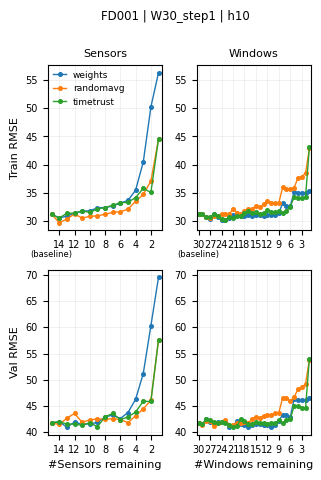

In [8]:
plot_rankings_metric_evolution_2x2_ieee(
    "FD001", "W30_step1", "h10",
    metric="rmse",
    transform="raw",   # o "ratio"
)

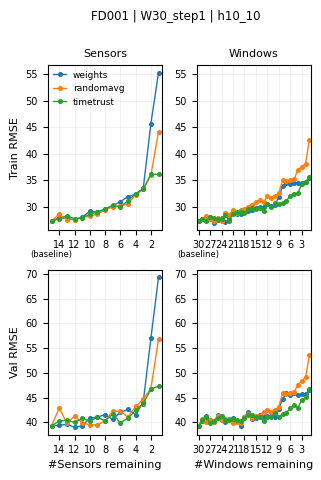

In [9]:
plot_rankings_metric_evolution_2x2_ieee(
    "FD001", "W30_step1", "h10_10",
    metric="rmse",
    transform="raw",   # o "ratio"
)

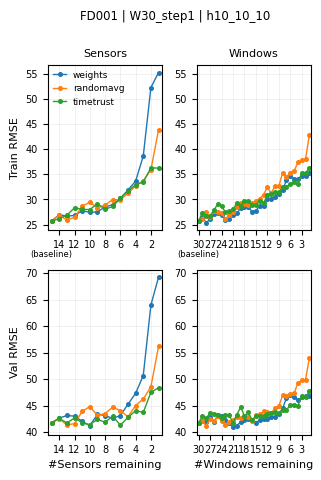

In [10]:
plot_rankings_metric_evolution_2x2_ieee(
    "FD001", "W30_step1", "h10_10_10",
    metric="rmse",
    transform="raw",   # o "ratio"
)

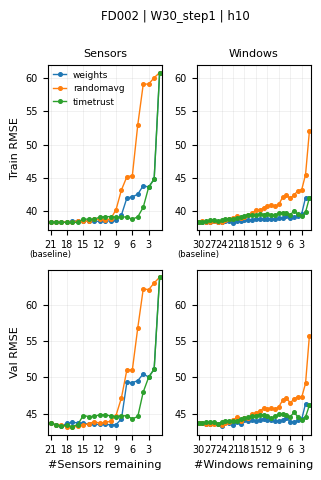

In [11]:
plot_rankings_metric_evolution_2x2_ieee(
    "FD002", "W30_step1", "h10",
    metric="rmse",
    transform="raw",   # o "ratio"
)

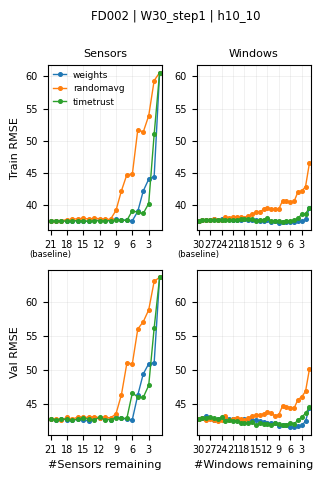

In [12]:
plot_rankings_metric_evolution_2x2_ieee(
    "FD002", "W30_step1", "h10_10",
    metric="rmse",
    transform="raw",   # o "ratio"
)

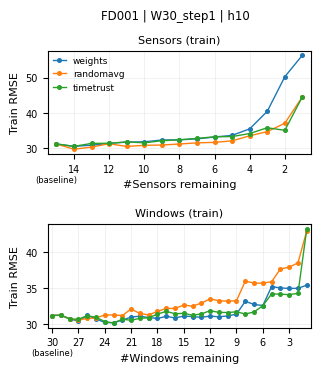

In [53]:
plot_rankings_metric_evolution_train_2x1_ieee(
    "FD001", "W30_step1", "h10",
    metric="rmse",
    transform="raw",
    y_scale="linear",
)

In [3]:
import numpy as np

def plot_metric_auc_band_ieee_2row(
    dataset: str,
    window_tag: str,
    hidden_tag: str,
    group_mode: GroupMode,
    metric: str = "rmse",
    baselines_root: str | Path = "mlp_baselines",
    band_hi: float = 1.00,
    band_lo: float = 0.30,
    figsize: Tuple[float, float] = (3.4, 3.8),  # taller
    save_path: Optional[str | Path] = None,
    y_scale: YScale = "linear",
    y_clip_percentiles: Optional[Tuple[float, float]] = None,
) -> Dict[str, Dict[str, float]]:
    """
    Two-row plot: Train (top) / Val (bottom).
    Computes normalized AUC in [band_lo, band_hi] for each split.
    """

    baselines_root = Path(baselines_root)
    json_path = (
        baselines_root
        / dataset
        / window_tag
        / hidden_tag
        / "rankings"
        / "rankings_metrics_evolution.json"
    )

    if not json_path.exists():
        raise FileNotFoundError(f"Missing metrics evolution JSON at: {json_path}")

    with open(json_path, "r", encoding="utf-8") as f:
        data: Dict[str, Any] = json.load(f)

    results: Dict[str, Any] = data.get("results", {})
    if not results:
        raise ValueError(f"No 'results' found in: {json_path}")

    if group_mode == "sensors":
        n_groups = int(data["M"])
        xlabel = "% sensors remaining"
    else:
        n_groups = int(data["W"])
        xlabel = "% windows remaining"

    sources: List[Tuple[RankingSource, str]] = [
        ("weights", "weights"),
        ("randomavg", "randomavg"),
        ("timetrust", "timetrust"),
    ]

    def _get_vec(src: str) -> Optional[List[Dict[str, Any]]]:
        k = f"{group_mode}.{src}"
        return results.get(k, {}).get("metrics_vector", None)

    def _x_percent(vec):
        rem = np.array(
            [n_groups - int(step["removed_groups_count"]) for step in vec],
            dtype=int,
        )
        return rem / float(n_groups)

    def _y_metric(vec, split):
        key_metric = f"{split}_{metric}"
        y = []
        for step in vec:
            fm = step.get("final_metrics", {})
            if key_metric not in fm:
                raise KeyError(
                    f"Missing metric '{key_metric}' in final_metrics. "
                    f"Keys={list(fm.keys())}"
                )
            y.append(float(fm[key_metric]))
        return np.asarray(y, dtype=float)

    def _auc_in_band(x, y, lo, hi):
        order = np.argsort(x)
        xs = x[order]
        ys = y[order]

        lo = float(lo)
        hi = float(hi)
        if lo > hi:
            lo, hi = hi, lo

        mask = (xs >= lo) & (xs <= hi)
        xs_in = xs[mask]
        ys_in = ys[mask]

        def _interp(xq):
            return float(np.interp(xq, xs, ys))

        if xs_in.size == 0:
            xs_in = np.array([lo, hi], dtype=float)
            ys_in = np.array([_interp(lo), _interp(hi)], dtype=float)
        else:
            if xs_in[0] > lo:
                xs_in = np.insert(xs_in, 0, lo)
                ys_in = np.insert(ys_in, 0, _interp(lo))
            if xs_in[-1] < hi:
                xs_in = np.append(xs_in, hi)
                ys_in = np.append(ys_in, _interp(hi))

        auc = float(np.trapz(ys_in, xs_in))
        width = max(1e-12, (hi - lo))
        return auc / width

    fig, axes = plt.subplots(
        2, 1, sharex=True, figsize=figsize, constrained_layout=True
    )

    splits = ["train", "val"]
    aucs_all: Dict[str, Dict[str, float]] = {}

    for ax, split in zip(axes, splits):

        ax.axvspan(band_lo, band_hi, alpha=0.12)
        all_y = []
        aucs_split: Dict[str, float] = {}

        for label, src in sources:

            vec = _get_vec(src)
            if vec is None:
                continue

            x = _x_percent(vec)
            y = _y_metric(vec, split)

            auc_band = _auc_in_band(x, y, band_lo, band_hi)
            aucs_split[src] = auc_band

            ax.plot(
                x,
                y,
                marker="o",
                linewidth=1.0,
                markersize=2.6,
                label=f"{label} (AUC={auc_band:.5g})",
            )

            all_y.append(y)

        # Y scale
        if y_scale == "log":
            ymin = np.nanmin(np.concatenate(all_y)) if all_y else 1.0
            if ymin <= 0:
                raise ValueError("y_scale='log' requires y > 0.")
            ax.set_yscale("log")

        elif y_scale == "symlog":
            ax.set_yscale("symlog", linthresh=1e-6)

        else:
            ax.set_yscale("linear")

        if y_clip_percentiles is not None and all_y:
            p_lo, p_hi = y_clip_percentiles
            ycat = np.concatenate(all_y)

            lo = float(np.percentile(ycat, p_lo))
            hi = float(np.percentile(ycat, p_hi))

            if lo == hi:
                hi = lo + 1e-9

            ax.set_ylim(lo, hi)

        ax.grid(True, alpha=0.25, linewidth=0.5)
        ax.tick_params(axis="both", labelsize=7)
        ax.set_ylabel(f"{split.title()} {metric.upper()}", fontsize=8)

        aucs_all[split] = aucs_split

    # X axis (shared)
    axes[-1].set_xlim(1.02, -0.02)
    axes[-1].xaxis.set_major_locator(MaxNLocator(nbins=6))
    axes[-1].set_xlabel(xlabel, fontsize=8)

    for ax in axes:
        ax.legend(loc="best", fontsize=6.5, frameon=False, handlelength=1.4, borderaxespad=0.2)


    fig.suptitle(
        f"{dataset} | {window_tag} | {hidden_tag} | {group_mode}",
        fontsize=8.5,
    )

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight", pad_inches=0.01)

    plt.show()

    return aucs_all

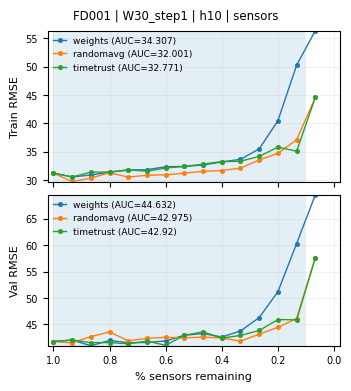

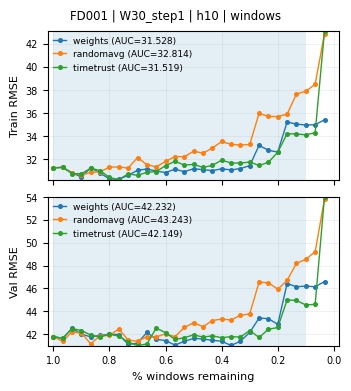

In [4]:
aucs = plot_metric_auc_band_ieee_2row(
    dataset="FD001",
    window_tag="W30_step1",
    hidden_tag="h10",
    group_mode="sensors",
    metric="rmse",
    baselines_root="mlp_baselines",
    band_hi=1.00,
    band_lo=0.10,
    figsize=(3.4, 3.8),
    y_scale="linear",
    y_clip_percentiles=(0, 100),
)

aucs = plot_metric_auc_band_ieee_2row(
    dataset="FD001",
    window_tag="W30_step1",
    hidden_tag="h10",
    group_mode="windows",
    metric="rmse",
    baselines_root="mlp_baselines",
    band_hi=1.00,
    band_lo=0.10,
    figsize=(3.4, 3.8),
    y_scale="linear",
    y_clip_percentiles=(0, 100),
)

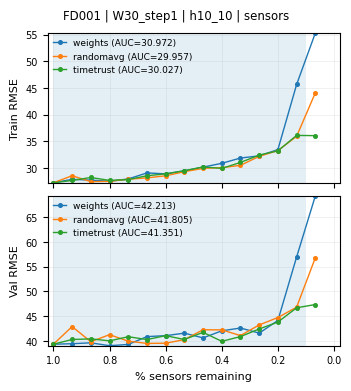

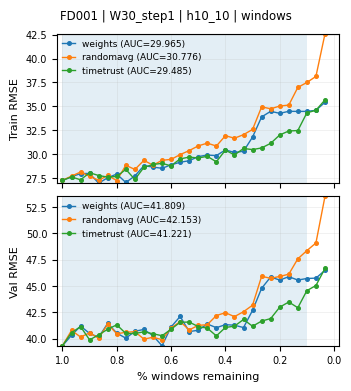

In [38]:
aucs = plot_metric_auc_band_ieee_2row(
    dataset="FD001",
    window_tag="W30_step1",
    hidden_tag="h10_10",
    group_mode="sensors",
    metric="rmse",
    baselines_root="mlp_baselines",
    band_hi=1.00,
    band_lo=0.10,
    figsize=(3.4, 3.8),
    y_scale="linear",
    y_clip_percentiles=(0, 100),
)

aucs = plot_metric_auc_band_ieee_2row(
    dataset="FD001",
    window_tag="W30_step1",
    hidden_tag="h10_10",
    group_mode="windows",
    metric="rmse",
    baselines_root="mlp_baselines",
    band_hi=1.00,
    band_lo=0.10,
    figsize=(3.4, 3.8),
    y_scale="linear",
    y_clip_percentiles=(0, 100),
)

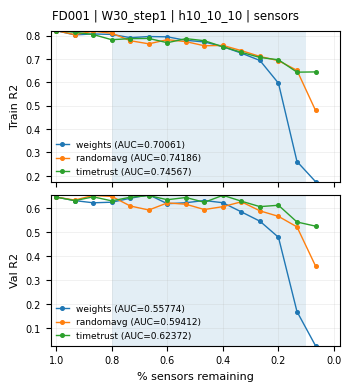

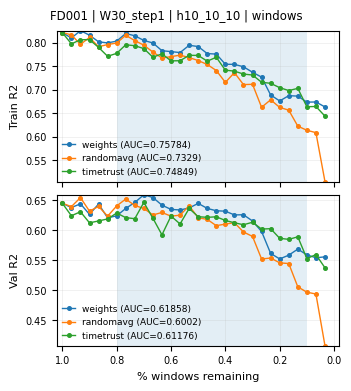

In [ ]:
aucs = plot_metric_auc_band_ieee_2row(
    dataset="FD001",
    window_tag="W30_step1",
    hidden_tag="h10_10_10",
    group_mode="sensors",
    metric="mae",
    baselines_root="mlp_baselines",
    band_hi=0.80,
    band_lo=0.10,
    figsize=(3.4, 3.8),
    y_scale="linear",
    y_clip_percentiles=(0, 100),
)

aucs = plot_metric_auc_band_ieee_2row(
    dataset="FD001",
    window_tag="W30_step1",
    hidden_tag="h10_10_10",
    group_mode="windows",
    metric="mae",
    baselines_root="mlp_baselines",
    band_hi=0.80,
    band_lo=0.10,
    figsize=(3.4, 3.8),
    y_scale="linear",
    y_clip_percentiles=(0, 100),
)

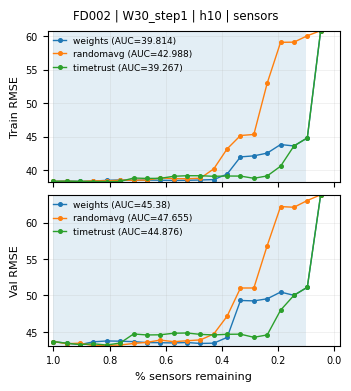

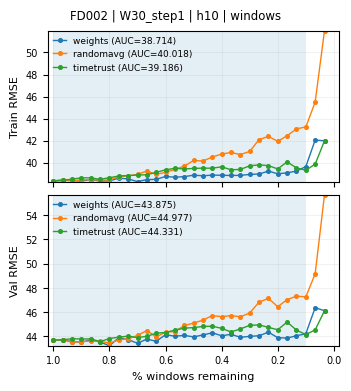

In [41]:
aucs = plot_metric_auc_band_ieee_2row(
    dataset="FD002",
    window_tag="W30_step1",
    hidden_tag="h10",
    group_mode="sensors",
    metric="rmse",
    baselines_root="mlp_baselines",
    band_hi=1.00,
    band_lo=0.10,
    figsize=(3.4, 3.8),
    y_scale="linear",
    y_clip_percentiles=(0, 100),
)

aucs = plot_metric_auc_band_ieee_2row(
    dataset="FD002",
    window_tag="W30_step1",
    hidden_tag="h10",
    group_mode="windows",
    metric="rmse",
    baselines_root="mlp_baselines",
    band_hi=1.00,
    band_lo=0.10,
    figsize=(3.4, 3.8),
    y_scale="linear",
    y_clip_percentiles=(0, 100),
)

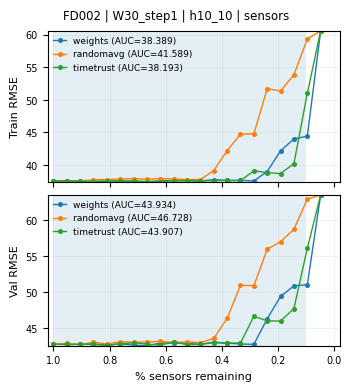

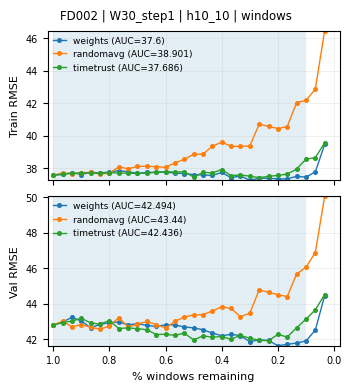

In [42]:
aucs = plot_metric_auc_band_ieee_2row(
    dataset="FD002",
    window_tag="W30_step1",
    hidden_tag="h10_10",
    group_mode="sensors",
    metric="rmse",
    baselines_root="mlp_baselines",
    band_hi=1.00,
    band_lo=0.10,
    figsize=(3.4, 3.8),
    y_scale="linear",
    y_clip_percentiles=(0, 100),
)

aucs = plot_metric_auc_band_ieee_2row(
    dataset="FD002",
    window_tag="W30_step1",
    hidden_tag="h10_10",
    group_mode="windows",
    metric="rmse",
    baselines_root="mlp_baselines",
    band_hi=1.00,
    band_lo=0.10,
    figsize=(3.4, 3.8),
    y_scale="linear",
    y_clip_percentiles=(0, 100),
)

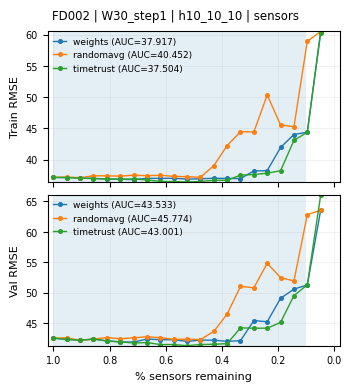

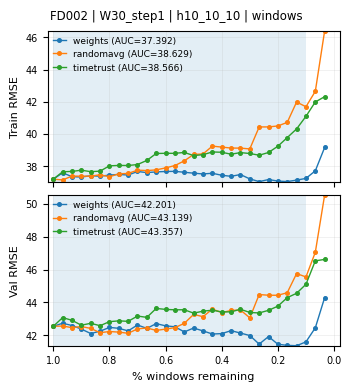

In [43]:
aucs = plot_metric_auc_band_ieee_2row(
    dataset="FD002",
    window_tag="W30_step1",
    hidden_tag="h10_10_10",
    group_mode="sensors",
    metric="rmse",
    baselines_root="mlp_baselines",
    band_hi=1.00,
    band_lo=0.10,
    figsize=(3.4, 3.8),
    y_scale="linear",
    y_clip_percentiles=(0, 100),
)

aucs = plot_metric_auc_band_ieee_2row(
    dataset="FD002",
    window_tag="W30_step1",
    hidden_tag="h10_10_10",
    group_mode="windows",
    metric="rmse",
    baselines_root="mlp_baselines",
    band_hi=1.00,
    band_lo=0.10,
    figsize=(3.4, 3.8),
    y_scale="linear",
    y_clip_percentiles=(0, 100),
)

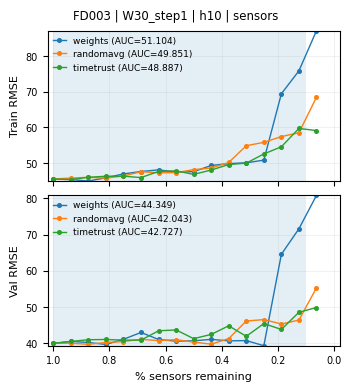

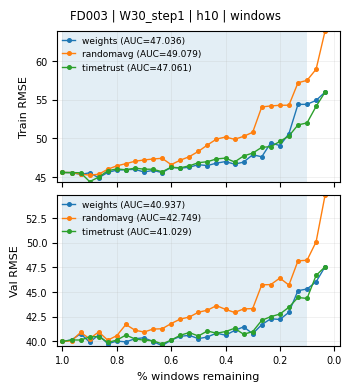

In [44]:
aucs = plot_metric_auc_band_ieee_2row(
    dataset="FD003",
    window_tag="W30_step1",
    hidden_tag="h10",
    group_mode="sensors",
    metric="rmse",
    baselines_root="mlp_baselines",
    band_hi=1.00,
    band_lo=0.10,
    figsize=(3.4, 3.8),
    y_scale="linear",
    y_clip_percentiles=(0, 100),
)

aucs = plot_metric_auc_band_ieee_2row(
    dataset="FD003",
    window_tag="W30_step1",
    hidden_tag="h10",
    group_mode="windows",
    metric="rmse",
    baselines_root="mlp_baselines",
    band_hi=1.00,
    band_lo=0.10,
    figsize=(3.4, 3.8),
    y_scale="linear",
    y_clip_percentiles=(0, 100),
)

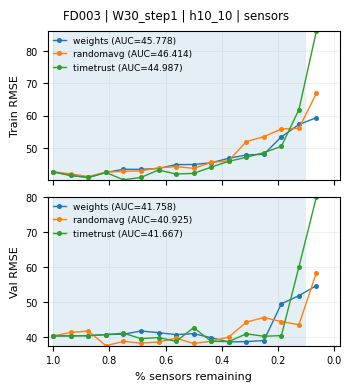

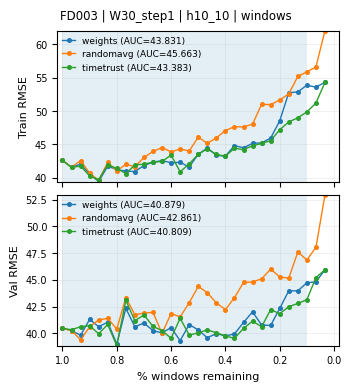

In [45]:
aucs = plot_metric_auc_band_ieee_2row(
    dataset="FD003",
    window_tag="W30_step1",
    hidden_tag="h10_10",
    group_mode="sensors",
    metric="rmse",
    baselines_root="mlp_baselines",
    band_hi=1.00,
    band_lo=0.10,
    figsize=(3.4, 3.8),
    y_scale="linear",
    y_clip_percentiles=(0, 100),
)

aucs = plot_metric_auc_band_ieee_2row(
    dataset="FD003",
    window_tag="W30_step1",
    hidden_tag="h10_10",
    group_mode="windows",
    metric="rmse",
    baselines_root="mlp_baselines",
    band_hi=1.00,
    band_lo=0.10,
    figsize=(3.4, 3.8),
    y_scale="linear",
    y_clip_percentiles=(0, 100),
)

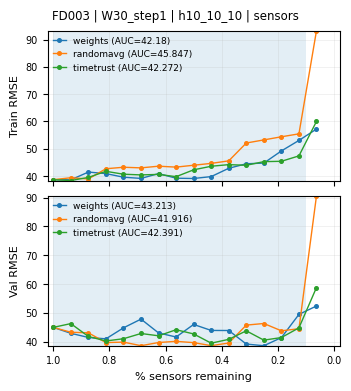

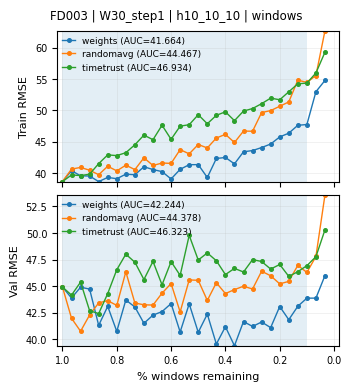

In [50]:
aucs = plot_metric_auc_band_ieee_2row(
    dataset="FD003",
    window_tag="W30_step1",
    hidden_tag="h10_10_10",
    group_mode="sensors",
    metric="rmse",
    baselines_root="mlp_baselines",
    band_hi=1.00,
    band_lo=0.10,
    figsize=(3.4, 3.8),
    y_scale="linear",
    y_clip_percentiles=(0, 100),
)

aucs = plot_metric_auc_band_ieee_2row(
    dataset="FD003",
    window_tag="W30_step1",
    hidden_tag="h10_10_10",
    group_mode="windows",
    metric="rmse",
    baselines_root="mlp_baselines",
    band_hi=1.00,
    band_lo=0.10,
    figsize=(3.4, 3.8),
    y_scale="linear",
    y_clip_percentiles=(0, 100),
)

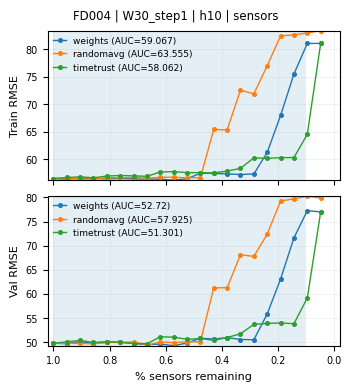

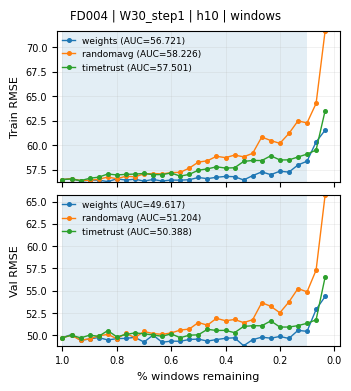

In [51]:
aucs = plot_metric_auc_band_ieee_2row(
    dataset="FD004",
    window_tag="W30_step1",
    hidden_tag="h10",
    group_mode="sensors",
    metric="rmse",
    baselines_root="mlp_baselines",
    band_hi=1.00,
    band_lo=0.10,
    figsize=(3.4, 3.8),
    y_scale="linear",
    y_clip_percentiles=(0, 100),
)

aucs = plot_metric_auc_band_ieee_2row(
    dataset="FD004",
    window_tag="W30_step1",
    hidden_tag="h10",
    group_mode="windows",
    metric="rmse",
    baselines_root="mlp_baselines",
    band_hi=1.00,
    band_lo=0.10,
    figsize=(3.4, 3.8),
    y_scale="linear",
    y_clip_percentiles=(0, 100),
)

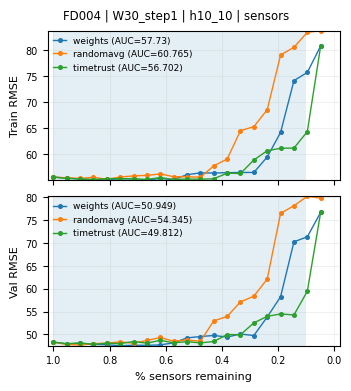

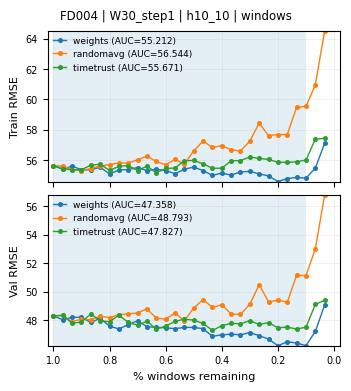

In [52]:
aucs = plot_metric_auc_band_ieee_2row(
    dataset="FD004",
    window_tag="W30_step1",
    hidden_tag="h10_10",
    group_mode="sensors",
    metric="rmse",
    baselines_root="mlp_baselines",
    band_hi=1.00,
    band_lo=0.10,
    figsize=(3.4, 3.8),
    y_scale="linear",
    y_clip_percentiles=(0, 100),
)

aucs = plot_metric_auc_band_ieee_2row(
    dataset="FD004",
    window_tag="W30_step1",
    hidden_tag="h10_10",
    group_mode="windows",
    metric="rmse",
    baselines_root="mlp_baselines",
    band_hi=1.00,
    band_lo=0.10,
    figsize=(3.4, 3.8),
    y_scale="linear",
    y_clip_percentiles=(0, 100),
)

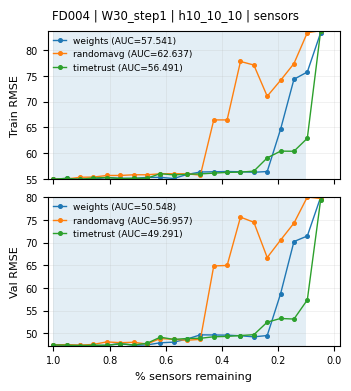

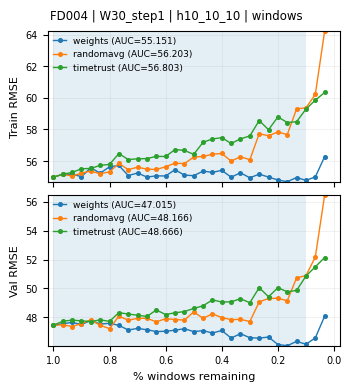

In [53]:
aucs = plot_metric_auc_band_ieee_2row(
    dataset="FD004",
    window_tag="W30_step1",
    hidden_tag="h10_10_10",
    group_mode="sensors",
    metric="rmse",
    baselines_root="mlp_baselines",
    band_hi=1.00,
    band_lo=0.10,
    figsize=(3.4, 3.8),
    y_scale="linear",
    y_clip_percentiles=(0, 100),
)

aucs = plot_metric_auc_band_ieee_2row(
    dataset="FD004",
    window_tag="W30_step1",
    hidden_tag="h10_10_10",
    group_mode="windows",
    metric="rmse",
    baselines_root="mlp_baselines",
    band_hi=1.00,
    band_lo=0.10,
    figsize=(3.4, 3.8),
    y_scale="linear",
    y_clip_percentiles=(0, 100),
)

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple, Literal

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

GroupMode = Literal["sensors", "windows"]
RankingSource = Literal["weights", "randomavg", "timetrust"]
YScale = Literal["linear", "log", "symlog"]


def plot_auc_band_2x2_ieee(
    dataset: str,
    window_tag: str,
    hidden_tag: str,
    baselines_root: str | Path = "mlp_baselines",
    band_hi: float = 1.00,
    band_lo: float = 0.30,
    figsize: Tuple[float, float] = (3.8, 4.6),  # a bit wider for IEEE
    save_path: Optional[str | Path] = None,
    split: Literal["val", "train"] = "val",      # paper default: validation curves
    y_scale_rmse: YScale = "linear",
    y_scale_r2: YScale = "linear",
    y_clip_percentiles_rmse: Optional[Tuple[float, float]] = None,
    y_clip_percentiles_r2: Optional[Tuple[float, float]] = None,
) -> Dict[str, Dict[str, Dict[str, float]]]:
    """
    IEEE-style compact 2x2 grid:
      Rows: Sensors (top) | Windows (bottom)
      Cols: RMSE (left)   | R^2 (right)

    Each subplot shows the 3 sources (weights/randomavg/timetrust).
    The normalized AUC in [band_lo, band_hi] is printed below each subplot,
    and the legend only shows method names (cleaner for IEEE).

    Returns:
      aucs[group_mode][metric][src] = auc_value
    """

    baselines_root = Path(baselines_root)
    json_path = (
        baselines_root
        / dataset
        / window_tag
        / hidden_tag
        / "rankings"
        / "rankings_metrics_evolution.json"
    )
    if not json_path.exists():
        raise FileNotFoundError(f"Missing metrics evolution JSON at: {json_path}")

    with open(json_path, "r", encoding="utf-8") as f:
        data: Dict[str, Any] = json.load(f)

    results: Dict[str, Any] = data.get("results", {})
    if not results:
        raise ValueError(f"No 'results' found in: {json_path}")

    sources: List[Tuple[RankingSource, str]] = [
        ("weights", "weights"),
        ("randomavg", "randomavg"),
        ("timetrust", "timetrust"),
    ]

    def _get_vec(group_mode: GroupMode, src: str) -> Optional[List[Dict[str, Any]]]:
        k = f"{group_mode}.{src}"
        vec = results.get(k, {}).get("metrics_vector", None)
        return vec if vec else None

    def _n_groups(group_mode: GroupMode) -> int:
        # In your JSON, "M" stores number of groups for sensors mode, and "W" for windows mode.
        if group_mode == "sensors":
            if "M" not in data:
                raise KeyError(f"Missing 'M' in JSON (needed for sensors). Path={json_path}")
            return int(data["M"])
        if group_mode == "windows":
            if "W" not in data:
                raise KeyError(f"Missing 'W' in JSON (needed for windows). Path={json_path}")
            return int(data["W"])
        raise ValueError(f"Invalid group_mode={group_mode}")

    def _x_percent(group_mode: GroupMode, vec: List[Dict[str, Any]]) -> np.ndarray:
        n = _n_groups(group_mode)
        rem = np.array([n - int(step["removed_groups_count"]) for step in vec], dtype=int)
        return rem / float(n)

    def _y_metric(vec: List[Dict[str, Any]], split_: str, metric: str) -> np.ndarray:
        key_metric = f"{split_}_{metric}"
        y = []
        for step in vec:
            fm = step.get("final_metrics", {})
            if key_metric not in fm:
                raise KeyError(
                    f"Missing metric '{key_metric}' in final_metrics. "
                    f"Keys={list(fm.keys())}"
                )
            y.append(float(fm[key_metric]))
        return np.asarray(y, dtype=float)

    def _auc_in_band(x: np.ndarray, y: np.ndarray, lo: float, hi: float) -> float:
        order = np.argsort(x)
        xs = x[order]
        ys = y[order]

        lo = float(lo)
        hi = float(hi)
        if lo > hi:
            lo, hi = hi, lo

        mask = (xs >= lo) & (xs <= hi)
        xs_in = xs[mask]
        ys_in = ys[mask]

        def _interp(xq: float) -> float:
            return float(np.interp(xq, xs, ys))

        if xs_in.size == 0:
            xs_in = np.array([lo, hi], dtype=float)
            ys_in = np.array([_interp(lo), _interp(hi)], dtype=float)
        else:
            if xs_in[0] > lo:
                xs_in = np.insert(xs_in, 0, lo)
                ys_in = np.insert(ys_in, 0, _interp(lo))
            if xs_in[-1] < hi:
                xs_in = np.append(xs_in, hi)
                ys_in = np.append(ys_in, _interp(hi))

        auc = float(np.trapz(ys_in, xs_in))
        width = max(1e-12, (hi - lo))
        return auc / width

    def _decorate_ax(
        ax: plt.Axes,
        title: str,
        ylabel: str,
        y_scale: YScale,
        y_clip_percentiles: Optional[Tuple[float, float]],
        all_y: List[np.ndarray],
    ) -> None:
        ax.set_title(title, fontsize=8)
        ax.set_ylabel(ylabel, fontsize=8)
        ax.grid(True, alpha=0.25, linewidth=0.5)
        ax.tick_params(axis="both", labelsize=7)

        if y_scale == "log":
            ymin = np.nanmin(np.concatenate(all_y)) if all_y else 1.0
            if ymin <= 0:
                raise ValueError("y_scale='log' requires y > 0.")
            ax.set_yscale("log")
        elif y_scale == "symlog":
            ax.set_yscale("symlog", linthresh=1e-6)
        else:
            ax.set_yscale("linear")

        if y_clip_percentiles is not None and all_y:
            p_lo, p_hi = y_clip_percentiles
            ycat = np.concatenate(all_y)
            lo = float(np.percentile(ycat, p_lo))
            hi = float(np.percentile(ycat, p_hi))
            if lo == hi:
                hi = lo + 1e-9
            ax.set_ylim(lo, hi)

        # decreasing left->right (baseline -> 1), since x is % remaining
        ax.set_xlim(1.02, -0.02)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=6))

    def _write_auc_text(ax: plt.Axes) -> None:
        aucs_here = getattr(ax, "_auc_values", None)
        if not aucs_here:
            return

        # Nice ordering + short labels
        parts = []
        if "timetrust" in aucs_here:
            parts.append(f"TT={aucs_here['timetrust']:.3f}")
        if "weights" in aucs_here:
            parts.append(f"W={aucs_here['weights']:.3f}")
        if "randomavg" in aucs_here:
            parts.append(f"R={aucs_here['randomavg']:.3f}")

        txt = "AUC: " + " | ".join(parts)

        ax.text(
            0.5,
            -0.32,  # tweak if you want it closer/farther
            txt,
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=6.5,
        )

    def _plot_panel(ax: plt.Axes, group_mode: GroupMode, metric: str) -> Dict[str, float]:
        ax.axvspan(band_lo, band_hi, alpha=0.12)

        aucs_here: Dict[str, float] = {}
        all_y: List[np.ndarray] = []

        for label, src in sources:
            vec = _get_vec(group_mode, src)
            if vec is None:
                continue

            x = _x_percent(group_mode, vec)
            y = _y_metric(vec, split, metric)

            auc = _auc_in_band(x, y, band_lo, band_hi)
            aucs_here[src] = auc

            ax.plot(
                x,
                y,
                marker="o",
                linewidth=1.0,
                markersize=2.6,
                label=label,  # clean legend
            )
            all_y.append(y)

        # stash for decoration + auc text
        ax._all_y_for_clip = all_y  # type: ignore[attr-defined]
        ax._auc_values = aucs_here  # type: ignore[attr-defined]
        return aucs_here

    # ---- Figure layout (2x2) ----
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 2, hspace=0.54, wspace=0.58)  # a bit more hspace for AUC text

    ax_s_rmse = fig.add_subplot(gs[0, 0])
    ax_s_r2 = fig.add_subplot(gs[0, 1], sharex=ax_s_rmse)
    ax_w_rmse = fig.add_subplot(gs[1, 0], sharex=ax_s_rmse)
    ax_w_r2 = fig.add_subplot(gs[1, 1], sharex=ax_s_rmse)

    # Plot all panels
    aucs: Dict[str, Dict[str, Dict[str, float]]] = {"sensors": {}, "windows": {}}
    aucs["sensors"]["rmse"] = _plot_panel(ax_s_rmse, "sensors", "rmse")
    aucs["sensors"]["r2"] = _plot_panel(ax_s_r2, "sensors", "r2")
    aucs["windows"]["rmse"] = _plot_panel(ax_w_rmse, "windows", "rmse")
    aucs["windows"]["r2"] = _plot_panel(ax_w_r2, "windows", "r2")

    # Decorate axes
    _decorate_ax(
        ax_s_rmse,
        title="Sensor-wise",
        ylabel=f"{split.title()} RMSE",
        y_scale=y_scale_rmse,
        y_clip_percentiles=y_clip_percentiles_rmse,
        all_y=getattr(ax_s_rmse, "_all_y_for_clip", []),
    )
    _decorate_ax(
        ax_s_r2,
        title="Sensor-wise",
        ylabel=f"{split.title()} $R^2$",
        y_scale=y_scale_r2,
        y_clip_percentiles=y_clip_percentiles_r2,
        all_y=getattr(ax_s_r2, "_all_y_for_clip", []),
    )
    _decorate_ax(
        ax_w_rmse,
        title="Window-wise",
        ylabel=f"{split.title()} RMSE",
        y_scale=y_scale_rmse,
        y_clip_percentiles=y_clip_percentiles_rmse,
        all_y=getattr(ax_w_rmse, "_all_y_for_clip", []),
    )
    _decorate_ax(
        ax_w_r2,
        title="Window-wise",
        ylabel=f"{split.title()} $R^2$",
        y_scale=y_scale_r2,
        y_clip_percentiles=y_clip_percentiles_r2,
        all_y=getattr(ax_w_r2, "_all_y_for_clip", []),
    )

    # AUC text below each subplot
    _write_auc_text(ax_s_rmse)
    _write_auc_text(ax_s_r2)
    _write_auc_text(ax_w_rmse)
    _write_auc_text(ax_w_r2)

    # X labels
    ax_s_rmse.set_xlabel("% groups remaining", fontsize=8)
    ax_s_r2.set_xlabel("% groups remaining", fontsize=8)
    ax_w_rmse.set_xlabel("% groups remaining", fontsize=8)
    ax_w_r2.set_xlabel("% groups remaining", fontsize=8)

    # Legend (single, compact)
    ax_s_rmse.legend(
        loc="best",
        fontsize=6.3,
        frameon=False,
        handlelength=1.4,
        borderaxespad=0.2,
    )

    fig.suptitle(
        f"{dataset} | {window_tag} | {hidden_tag} | {split.upper()} | band [{band_lo:.2f}, {band_hi:.2f}]",
        fontsize=8.5,
        y=0.995,
    )

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight", pad_inches=0.01)

    plt.show()
    return aucs

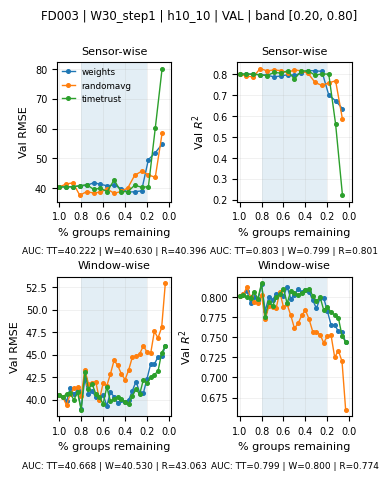

In [21]:
aucs = plot_auc_band_2x2_ieee(
    dataset="FD003",
    window_tag="W30_step1",
    hidden_tag="h10_10",
    band_lo=0.20,
    band_hi=0.80,
    split="val",
)

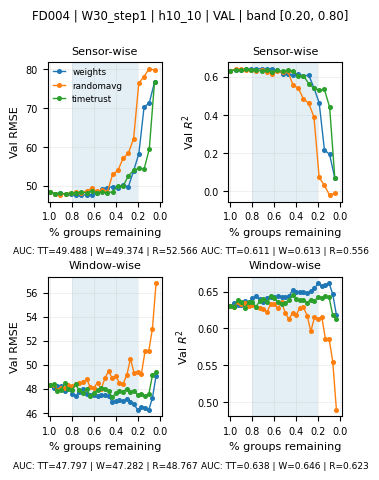

In [2]:
aucs = plot_auc_band_2x2_ieee(
    dataset="FD004",
    window_tag="W30_step1",
    hidden_tag="h10_10",
    band_lo=0.20,
    band_hi=0.80,
    split="val",
)